# 01 · The dataset: link channels, radar target, gauges and the event split

The proposal ([`docs/pre_projects/2d_project.md`](../../../../docs/pre_projects/2d_project.md))
learns a map $g_\theta:(\{Y_i\}, \mathcal{M}) \mapsto \hat R \in \mathbb{R}^{H\times W}$ from link
observations and network metadata, supervised by radar. This notebook builds the supervised
dataset that every later notebook (and the project's own models) reads, with
`core.maps.learning.build_network_dataset`:

| piece | how it is made (all from `core/`) |
|---|---|
| storm events | `core.events.detect_events` on the hourly radar of the whole record |
| link observations | metadata and time-series QC (`core.cml.link_qc`), constant-baseline power-law retrieval (`core.cml.estimators`), hour-ending totals |
| inputs on the grid | each link rasterized onto the radar grid along its path (`core.maps.learning.rasterize`) |
| target | the SMHI radar, hourly, on the network grid (`core.opensense.networks`) |
| gauges | 30 Netatmo PWS, 10 municipal gauges, 1 SMHI gauge: never an input, kept for the independent check |
| split | whole events to train / val / test, never single hours |

**Data.** OpenMRG, Gothenburg, June-August 2015 (Andersson et al., 2022,
[doi:10.5281/zenodo.7107689](https://doi.org/10.5281/zenodo.7107689)), read from the shared data
store (`DATA.md`). The proposal's own data, the Israeli network of the lab, is private; OpenMRG is
the open benchmark the diffusion-prior paper it cites (Moufad et al., 2026) also uses.

**Runtime:** about two minutes the first time (link retrieval for every event), seconds afterwards.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")    # PyTorch and other OpenMP users in one process

import sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects/maps/learned_2d/src"))

from core.data_paths import OUTPUTS
from core.maps import learning as ml

CACHE = OUTPUTS / "_learned_2d"          # generated files, not tracked
SPLIT_COLORS = {"train": "#3b6fb6", "val": "#e08a2e", "test": "#c03b3b"}
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
T0 = time.time()

## 1. Build (or read) the dataset

One call. Each event's link data and the final dataset are cached under
`dataset/open_datasets/_learned_2d/`; delete that folder to rebuild from the raw files.

In [2]:
t = time.time()
ds = ml.build_network_dataset("openmrg", cache_dir=CACHE)
print(f"{time.time() - t:.0f} s")
ds

106 s


<xarray.Dataset> Size: 13MB
Dimensions:           (time: 341, channel: 4, lat: 35, lon: 51, link: 354,
                       event: 27, station: 41)
Coordinates: (12/21)
  * lat               (lat) float64 280B 57.31 57.33 57.35 ... 57.95 57.97 57.99
  * lon               (lon) float64 408B 11.55 11.57 11.59 ... 12.51 12.53 12.55
  * time              (time) datetime64[ns] 3kB 2015-06-02T05:00:00 ... 2015-...
  * channel           (channel) <U11 176B 'rain' 'attenuation' ... 'length'
  * link              (link) <U7 10kB '10001/A' '10002/A' ... '10364/A'
  * event             (event) object 216B '20150602T04' ... '20150831T17'
    ...                ...
    polarization      (link) object 3kB 'v' 'v' 'v' 'v' 'v' ... 'v' 'v' 'v' 'v'
    length            (link) float64 3kB 0.6914 0.6146 0.3237 ... 4.806 1.412
  * station           (station) <U11 2kB 'pws_0' 'pws_1' ... 'smhi_SMHI'
    station_lat       (station) float64 328B 57.72 57.58 57.77 ... 57.63 57.72
    station_lon       (station) float64 328B 12.37 12.25 12.26 ... 11.94 11.99
    station_set       (station) <U4 656B 'pws' 'pws' 'pws' ... 'city' 'smhi'
Data variables:
    inputs            (time, channel, lat, lon) float32 10MB 0.0 0.0 ... 0.0 0.0
    target            (time, lat, lon) float32 2MB 0.3092 0.3242 ... 3.272 3.172
    link_rain         (link, time) float32 483kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    link_attenuation  (link, time) float32 483kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    distance_km       (lat, lon) float64 14kB 26.16 25.02 23.88 ... 11.22 12.17
    observable        (lat, lon) int8 2kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    event_start       (event) datetime64[ns] 216B 2015-06-02T04:00:00 ... 201...
    event_end         (event) datetime64[ns] 216B 2015-06-03T10:00:00 ... 201...
    event_split       (event) <U5 540B 'train' 'test' ... 'train' 'train'
    event_total_mm    (event) float64 216B 14.92 4.43 8.69 ... 28.03 1.25 10.83
    event_duration_h  (event) int64 216B 30 16 11 4 21 6 8 ... 12 12 21 24 6 7
    gauges            (station, time) float32 56kB 0.101 0.0 0.0 ... 3.3 4.0 2.0
Attributes:
    split_by:      storm event
    time_label:    end of step
    network:       openmrg
    retrieval:     constant
    split_how:     random
    split_seed:    0
    target:        radar, hourly accumulation (mm), hour-ending
    grid_res_deg:  0.02

## 2. Storm events and the split

`detect_events` finds the storms in the radar record (an hour is wet when the domain mean reaches
0.1 mm; storms separated by at least six dry hours are different events; storms under 1 mm are
dropped). The events are then shuffled with a fixed seed and dealt out whole, 60 / 20 / 20 %.
Hours of one storm are strongly correlated; splitting by hour would put the same storm on both
sides and report skill no model has.

In [3]:
events = ds[["event_start", "event_end", "event_split", "event_total_mm", "event_duration_h"]].to_dataframe()
events["hours_in_dataset"] = pd.Series(ds.event_id.values).value_counts().reindex(events.index).values
print(events.groupby("event_split").agg(events=("event_total_mm", "size"), hours=("hours_in_dataset", "sum"),
                                        total_mm=("event_total_mm", "sum")))
events.round(2)

             events  hours  total_mm
event_split                         
test              5    102     66.40
train            17    188    121.49
val               5     51     26.20


,event_start,event_end,event_split,event_total_mm,event_duration_h,hours_in_dataset
event,,,,,,
20150602T04,2015-06-02 04:00:00,2015-06-03 10:00:00,train,14.92,30,30
20150605T17,2015-06-05 17:00:00,2015-06-06 09:00:00,test,4.43,16,16
20150613T14,2015-06-13 14:00:00,2015-06-14 01:00:00,train,8.69,11,11
20150617T15,2015-06-17 15:00:00,2015-06-17 19:00:00,train,2.56,4,4
20150618T08,2015-06-18 08:00:00,2015-06-19 05:00:00,train,4.65,21,21
20150619T13,2015-06-19 13:00:00,2015-06-19 19:00:00,val,1.44,6,6
20150622T11,2015-06-22 11:00:00,2015-06-22 19:00:00,train,2.65,8,8
20150628T22,2015-06-28 22:00:00,2015-06-29 02:00:00,val,2.01,4,4
20150705T19,2015-07-05 19:00:00,2015-07-06 04:00:00,train,4.99,9,9


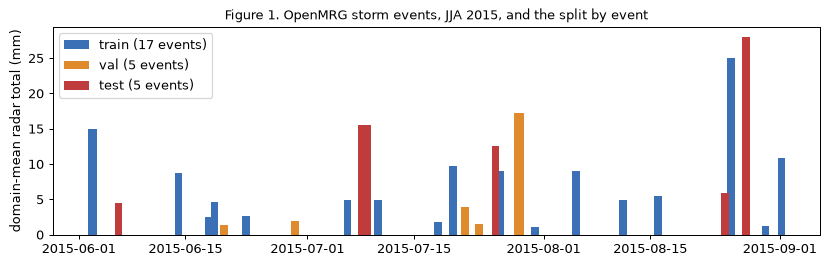

In [4]:
fig, ax = plt.subplots(figsize=(11, 3))
for split, color in SPLIT_COLORS.items():
    e = events[events.event_split == split]
    ax.bar(e.event_start, e.event_total_mm, width=pd.to_timedelta(e.event_duration_h, "h").clip(lower=pd.Timedelta("1D")),
           color=color, label=f"{split} ({len(e)} events)", align="edge")
ax.set(ylabel="domain-mean radar total (mm)", title="Figure 1. OpenMRG storm events, JJA 2015, and the split by event")
ax.legend(); plt.show()

# no event is in two splits, and every hour carries its event's split
assert (pd.Series(ds.split.values).groupby(ds.event_id.values).nunique() == 1).all()

## 3. The link table (input of graph models and of the classical baselines)

One row per sublink that passed QC in at least one event: endpoints, frequency, polarization and
length, the network metadata $\mathcal{M}$ of the proposal, and its hourly values
`link_rain(link, time)` (mm, power-law retrieval) and `link_attenuation(link, time)` (dB, the
hourly mean rain-induced attenuation $A$ that the retrieval inverts, clipped at 0). A link
missing in an hour is NaN there.

In [5]:
table = ds[["site_0_lat", "site_0_lon", "site_1_lat", "site_1_lon", "frequency", "polarization", "length"]].to_dataframe()
table["valid_hours"] = ds.link_rain.notnull().sum("time").values
print(f"{len(table)} links; frequency {table.frequency.min():.0f}-{table.frequency.max():.0f} GHz; "
      f"length {table.length.min():.1f}-{table.length.max():.1f} km (median {table.length.median():.1f}); "
      f"polarization {table.polarization.value_counts().to_dict()}; "
      f"{ds.link_rain.notnull().mean().item():.1%} of link-hours valid")
table.head()

354 links; frequency 15-39 GHz; length 0.3-12.6 km (median 2.3); polarization {'v': 352, 'h': 2}; 98.0% of link-hours valid


,site_0_lat,site_0_lon,site_1_lat,site_1_lon,frequency,polarization,length,mid_lat,mid_lon,valid_hours
link,,,,,,,,,,
10001/A,57.70368,11.99507,57.69785,11.99110,28.2065,v,0.69144,57.700765,11.993085,333
10002/A,57.72539,11.98181,57.72285,11.97265,38.5280,v,0.61455,57.724120,11.977230,341
10003/A,57.69247,11.97496,57.69406,11.97951,38.5280,v,0.32374,57.693265,11.977235,341
10004/A,57.70668,11.97285,57.70194,11.97488,28.2345,v,0.54124,57.704310,11.973865,341
10005/A,57.69318,11.95387,57.70321,11.95678,32.3610,v,1.12973,57.698195,11.955325,335


## 4. The inputs as channels on the grid

A CNN cannot read a list of lines, so each link is drawn onto the target grid along its path:
the path is cut into 50 m pieces and each piece falls into a cell. Per cell and hour,

* **rain**: mean of the links crossing the cell, each weighted by its path length in the cell;
* **attenuation**: the same for the specific attenuation $A/L$ (dB/km);
* **coverage**: km of valid link path in the cell (0 where no link: the model must know where it is blind);
* **length**: mean length of those links (a long link says less about any one of its cells).

Below, the wettest test hour: the four channels, the radar target and the gauges.

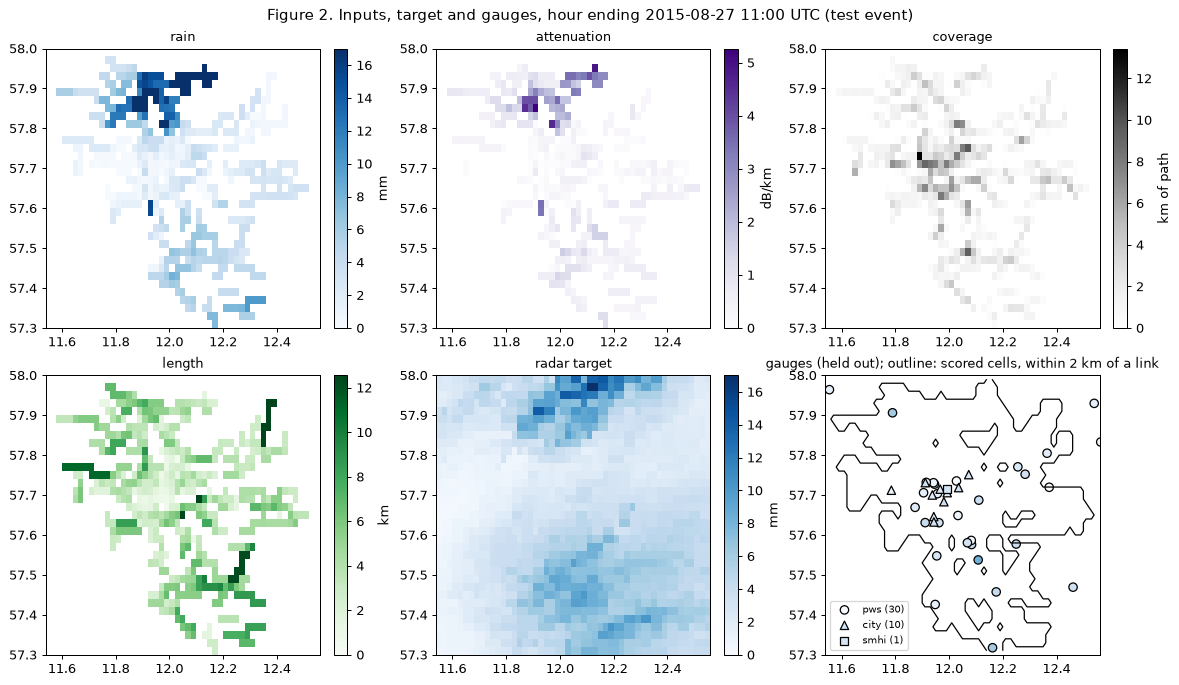

In [6]:
test = ds.sel(time=ds.split == "test")
mask = ds.observable.values.astype(bool)
hour = test.time.values[int(test.target.where(ds.observable == 1).mean(("lat", "lon")).argmax())]
x = ds.inputs.sel(time=hour)
lon2, lat2 = np.meshgrid(ds.lon, ds.lat)

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), constrained_layout=True)
panels = [("rain", x.sel(channel="rain"), "Blues", "mm"), ("attenuation", x.sel(channel="attenuation"), "Purples", "dB/km"),
          ("coverage", x.sel(channel="coverage"), "Greys", "km of path"), ("length", x.sel(channel="length"), "Greens", "km"),
          ("radar target", ds.target.sel(time=hour), "Blues", "mm")]
for ax, (name, da, cmap, unit) in zip(axes.flat, panels):
    vmax = float(ds.target.sel(time=hour).max()) if cmap == "Blues" else None
    pm = ax.pcolormesh(ds.lon, ds.lat, da.where(da > 0), cmap=cmap, vmin=0, vmax=vmax, shading="auto")
    fig.colorbar(pm, ax=ax, label=unit); ax.set_title(name)
ax = axes.flat[5]
ax.contour(ds.lon, ds.lat, mask, levels=[0.5], colors="k", linewidths=1)
g = ds.gauges.sel(time=hour)
for s, mk in [("pws", "o"), ("city", "^"), ("smhi", "s")]:
    sel = ds.station_set.values == s
    ax.scatter(ds.station_lon[sel], ds.station_lat[sel], c=g[sel], cmap="Blues", vmin=0, vmax=vmax,
               marker=mk, edgecolor="k", s=45, label=f"{s} ({sel.sum()})")
ax.set_xlim(axes.flat[0].get_xlim()); ax.set_ylim(axes.flat[0].get_ylim())
ax.set_title("gauges (held out); outline: scored cells, within 2 km of a link"); ax.legend(fontsize=8, loc="lower left")
fig.suptitle(f"Figure 2. Inputs, target and gauges, hour ending {pd.Timestamp(hour):%Y-%m-%d %H:%M} UTC (test event)")
plt.show()

## 5. Checks

The rasterization keeps the link measurements: summed over the grid, rain x coverage equals
$\sum_i L_i v_i$ in every hour (links that leave the grid lose the part outside). And the
discrete forward operator `ml.sample_paths` (field -> path averages; the operator a physics loss
or a posterior sampler needs) recovers each link's own value from the rain channel wherever it does
not share cells with another link.

In [7]:
W = ml.path_weights(ml.link_rain_of(ds), ml.Grid(ds.lat.values, ds.lon.values))
L = ds.length.values
r = ml.rasterize(ds.link_rain.values, W, L, (ds.sizes["lat"], ds.sizes["lon"]))
lhs = np.nansum(r["mean"] * r["coverage"], axis=(1, 2))
rhs = np.nansum(ds.link_rain.values * (W.sum(0) * L)[:, None], axis=0)
print(f"value x length conserved: max relative difference {np.nanmax(np.abs(lhs - rhs) / np.maximum(rhs, 1e-9)):.1e}; "
      f"share of path inside the grid {W.sum(0).min():.3f}-{W.sum(0).max():.3f}")

alone = (W > 0).sum(1) == 1                                      # cells crossed by one link only
own = np.array([alone[W[:, k] > 0].all() for k in range(W.shape[1])])
back = ml.sample_paths(r["mean"], W)
ok = own[:, None] & np.isfinite(ds.link_rain.values)
print(f"{own.sum()} links share no cell; their path average of the rain channel equals their value: "
      f"max |difference| {np.max(np.abs(back - ds.link_rain.values)[ok]):.1e} mm")

value x length conserved: max relative difference 1.3e-15; share of path inside the grid 1.000-1.000
5 links share no cell; their path average of the rain channel equals their value: max |difference| 1.8e-15 mm


## 6. What a model reads

`ml.arrays(ds, split)` gives plain arrays: `x (n, 4, H, W)`, `y (n, H, W)` (NaN where the radar has
no value) and the mask of scored cells. A graph model reads `ds.link_rain`, `ds.link_attenuation`
and the link coordinates instead (`ml.link_rain_of(ds)` puts them together).

In [8]:
for split in ml.SPLITS:
    a = ml.arrays(ds, split)
    print(f"{split:5s}  x {a['x'].shape}  y {a['y'].shape}  events {len(set(a['event_id']))}  "
          f"radar valid {np.isfinite(a['y']).mean():.1%}  wet hours (scored-cell mean >= 0.1 mm) "
          f"{(np.nanmean(a['y'][:, a['mask']], axis=1) >= 0.1).sum()}")
print(f"runtime {time.time() - T0:.0f} s")

train  x (188, 4, 35, 51)  y (188, 35, 51)  events 17  radar valid 100.0%  wet hours (scored-cell mean >= 0.1 mm) 158
val    x (51, 4, 35, 51)  y (51, 35, 51)  events 5  radar valid 100.0%  wet hours (scored-cell mean >= 0.1 mm) 41
test   x (102, 4, 35, 51)  y (102, 35, 51)  events 5  radar valid 100.0%  wet hours (scored-cell mean >= 0.1 mm) 75
runtime 110 s


**Next:** `02_baselines.ipynb` scores IDW, ordinary kriging and GMZ on the test events with the
proposal's metric table; `03_minimal_unet.ipynb` shows where a learned model plugs in.